In [59]:
import os
import uxarray as ux
from uxarray.core.dataset import UxDataset
from uxarray.core.dataarray import UxDataArray
from uxarray.grid.grid import Grid

import cartopy.crs as ccrs
import geoviews.feature as gf

In [12]:
grid_name: str = "C96"
case_name: str = "dcmip25-03"

In [74]:
def features(projection):
    return gf.coastline(projection = projection, linewidth = 1, scale = "50m")

In [43]:
grid_file_name: str = "{}_SCRIP_desc.181018.nc".format(grid_name)
grid_file_path: str = os.path.join("/glade", "campaign", "cesm", "cesmdata", "inputdata", "atm", "cam", "coords", grid_file_name)

data_file_name: str = "{}.cam.h0i.0001-01-01-00000.nc".format(case_name)
data_file_path: str = os.path.join("/glade", "work", "jltorch", "dcmip25", "dcmip25-03", "run", data_file_name)

In [18]:
ux_ds: UxDataset = ux.open_dataset(grid_file_path, data_file_path)

In [36]:
field_name: str = "RAD_REF"

In [37]:
field: UxDataArray = ux_ds[field_name]

In [38]:
projection: ccrs.Robinson = ccrs.Robinson()

In [41]:
field[0,0]

<xarray.UxDataArray 'RAD_REF' (n_face: 55296)> Size: 221kB
[55296 values with dtype=float32]
Coordinates:
    lev      float64 8B 49.09
    time     object 8B 0001-01-01 00:00:00
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         dBZ
    long_name:     radar_reflectivity
    cell_methods:  time: point

:Overlay
   .Image.I     :Image   [lon,lat]   (lon_lat var)
   .Coastline.I :Feature   [Longitude,Latitude]
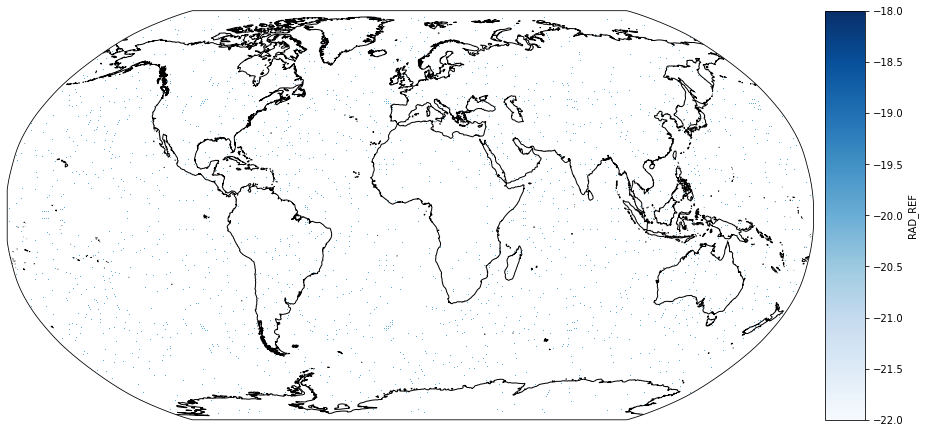

In [75]:
field[0,30].plot.rasterize(
    method = "point",
    projection = projection,
    backend = "matplotlib",
    pixel_ratio = 8.0,
    fig_size = 400,
) * features(projection)

In [71]:
fv3_mesh: Grid = ux.open_grid(grid_file_path, use_dual = False)

In [ ]:
(
    fv3_mesh.plot.edges(color = "black", line_width = 0.1)
).opts(
    title="FV3 Mesh",
    xlim=(-180, 180),
    ylim=(-90, 90),
    width = 700,
    height = 350,
)